<a href="https://colab.research.google.com/github/Veritax0/clasificacion-imagenes-redes-neuronales/blob/main/notebooks/01_baseline_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación Bart vs Homero — Implementación Base (CNN desde cero)

**Proyecto Deep Learning**  
Dataset: [Homer & Bart Classification (Kaggle)](https://www.kaggle.com/datasets/juniorbueno/neural-networks-homer-and-bart-classification/)

Este notebook implementa la **solución mínima**: una CNN en TensorFlow/Keras entrenada desde cero, que sirve como baseline para comparar mejoras posteriores.

> **Estructura del dataset:** todas las imágenes `.bmp` están en una sola carpeta, etiquetadas por nombre de archivo (e.g. `bart_001.bmp`, `homer_042.bmp`).

## 0. Instalación de dependencias

In [42]:
# Ejecutar solo si es necesario
# !pip install tensorflow matplotlib scikit-learn seaborn

## 1. Descarga del Dataset desde Kaggle

Necesitas un archivo `kaggle.json` con tus credenciales de API.  
Puedes generarlo en [kaggle.com → Settings → API → Create New Token](https://www.kaggle.com/settings).

**En Google Colab**, sube el archivo cuando se pida y ejecuta todas las celdas.

In [43]:
import os
DATASET_DIR = "data"

if not os.path.exists(DATASET_DIR):
    os.makedirs(DATASET_DIR, exist_ok=True)
    os.system(
        'kaggle datasets download '
        '-d juniorbueno/neural-networks-homer-and-bart-classification '
        f'--unzip -p {DATASET_DIR}'
    )
    print('Dataset descargado y descomprimido.')
else:
    print('Dataset ya existe, se omite la descarga.')

archivos = [f for f in os.listdir(DATASET_DIR + "/homer_bart_1") if f.lower().endswith('.bmp')]
print(f'Total de imágenes .bmp encontradas: {len(archivos)}')
print('Primeros 10 archivos:', archivos[:10])

Dataset ya existe, se omite la descarga.
Total de imágenes .bmp encontradas: 269
Primeros 10 archivos: ['homer101.bmp', 'homer60.bmp', 'bart23.bmp', 'bart148.bmp', 'homer57.bmp', 'bart60.bmp', 'homer41.bmp', 'bart125.bmp', 'homer105.bmp', 'bart53.bmp']


## 2. Imports y configuración

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ── Reproducibilidad ────────────────────────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow versión: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs disponibles: {gpus if gpus else 'Ninguna (usando CPU)'}")

# ── Hiperparámetros ─────────────────────────────────────────────────────────
IMG_SIZE    = 128
BATCH_SIZE  = 32
EPOCHS      = 30
LR          = 1e-3
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15
CLASS_NAMES = ['bart', 'homer']   # 0 = bart, 1 = homer

print(f"Imagen: {IMG_SIZE}x{IMG_SIZE} | Batch: {BATCH_SIZE} | Épocas: {EPOCHS} | LR: {LR}")

TensorFlow versión: 2.20.0
GPUs disponibles: Ninguna (usando CPU)
Imagen: 128x128 | Batch: 32 | Épocas: 30 | LR: 0.001


## 3. Carga del dataset

Todas las imágenes están en una sola carpeta en formato `.bmp`. La etiqueta se extrae del nombre del archivo: si contiene `'bart'` → clase 0, si contiene `'homer'` → clase 1.

In [45]:
def extraer_etiqueta(nombre_archivo):
    """
    Extrae la etiqueta numérica a partir del nombre del archivo.
    Retorna 0 para 'bart', 1 para 'homer', None si no reconoce.
    """
    nombre = nombre_archivo.lower()
    if 'bart' in nombre:
        return 0
    elif 'homer' in nombre:
        return 1
    return None


def cargar_dataset(directorio, img_size):
    """
    Lee todas las imágenes .bmp de una carpeta plana,
    extrae etiquetas del nombre de archivo y devuelve
    arrays NumPy (X, y).
    """
    rutas, etiquetas = [], []
    descartadas = []

    for archivo in sorted(os.listdir(directorio)):
        if not archivo.lower().endswith('.bmp'):
            continue
        etiqueta = extraer_etiqueta(archivo)
        if etiqueta is None:
            descartadas.append(archivo)
            continue
        rutas.append(os.path.join(directorio, archivo))
        etiquetas.append(etiqueta)

    if descartadas:
        print(f"  Archivos descartados (sin clase reconocible): {len(descartadas)}")
        print(f"  Ejemplos: {descartadas[:3]}")

    print(f"Leyendo {len(rutas)} imágenes...")
    X = np.zeros((len(rutas), img_size, img_size, 3), dtype=np.float32)
    for i, ruta in enumerate(rutas):
        raw = tf.io.read_file(ruta)
        # decode_bmp es específico para archivos BMP
        img = tf.image.decode_bmp(raw, channels=3)
        img = tf.image.resize(img, [img_size, img_size])
        X[i] = img.numpy()

    y = np.array(etiquetas, dtype=np.int32)
    return X, y


X, y = cargar_dataset(DATASET_DIR + "/homer_bart_1", IMG_SIZE)

print(f"\nDataset cargado:")
print(f"  X shape : {X.shape}  (N, H, W, C)")
print(f"  Bart  (0): {(y == 0).sum()} imágenes")
print(f"  Homer (1): {(y == 1).sum()} imágenes")
print(f"  Rango de píxeles: [{X.min():.0f}, {X.max():.0f}]")

Leyendo 269 imágenes...

Dataset cargado:
  X shape : (269, 128, 128, 3)  (N, H, W, C)
  Bart  (0): 160 imágenes
  Homer (1): 109 imágenes
  Rango de píxeles: [0, 255]


In [46]:
# ── Normalización: píxeles [0, 255] → [0, 1] ────────────────────────────────
X = X / 255.0

# ── Split estratificado train / val / test ───────────────────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=y
)
val_frac = VAL_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_frac, random_state=SEED, stratify=y_trainval
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"  Train → Bart: {(y_train==0).sum()}, Homer: {(y_train==1).sum()}")
print(f"  Val   → Bart: {(y_val==0).sum()},   Homer: {(y_val==1).sum()}")
print(f"  Test  → Bart: {(y_test==0).sum()},  Homer: {(y_test==1).sum()}")

Train: 187 | Val: 41 | Test: 41
  Train → Bart: 112, Homer: 75
  Val   → Bart: 24,   Homer: 17
  Test  → Bart: 24,  Homer: 17


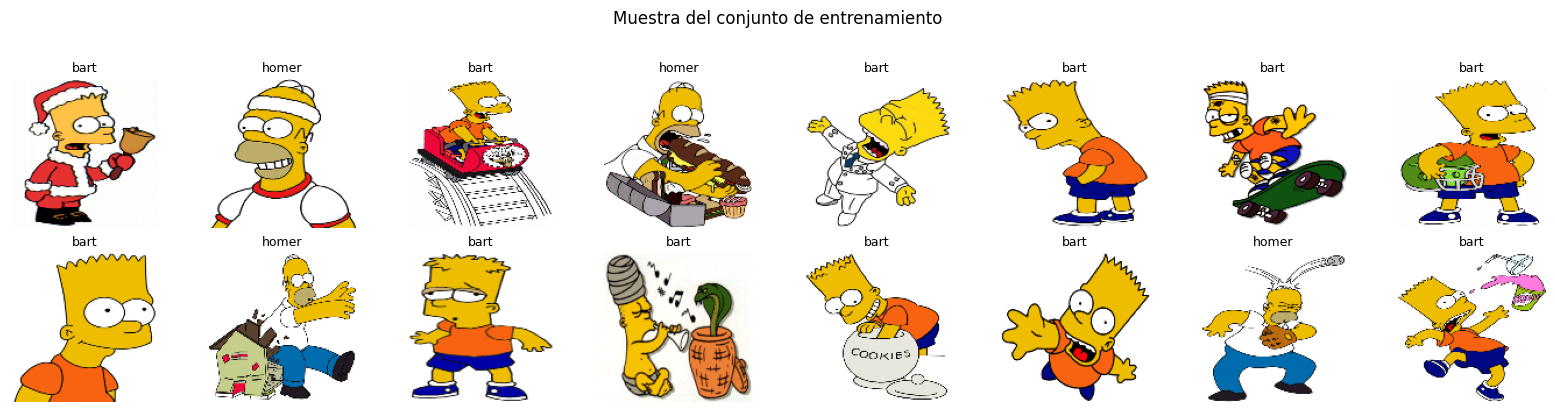

In [47]:
# ── Visualización de muestras ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
indices = np.random.choice(len(X_train), 16, replace=False)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[indices[i]])
    ax.set_title(CLASS_NAMES[y_train[indices[i]]], fontsize=9)
    ax.axis('off')

plt.suptitle('Muestra del conjunto de entrenamiento', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 4. Construcción del modelo CNN (baseline)

Red convolucional simple con 3 bloques `Conv2D → BatchNorm → ReLU → MaxPool` y un clasificador denso.

In [48]:
augmentation_ligero = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='augmentation_ligero')


def construir_cnn_baseline(img_size, num_classes=2):
    inputs = keras.Input(shape=(img_size, img_size, 3), name='imagen')

    x = augmentation_ligero(inputs)

    # Bloque 1
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    # Bloque 2
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    # Bloque 3
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    # Clasificador
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='prediccion')(x)

    return keras.Model(inputs, outputs, name='BaseCNN')


model = construir_cnn_baseline(IMG_SIZE)
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Model: "BaseCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen (InputLayer)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_ligero             │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediccion (Dense)              │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,834 (16.36 MB)

 Trainable params: 4,288,386 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 5. Entrenamiento

In [49]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_baseline_cnn.keras',
        monitor='val_loss',       # val_accuracy salta demasiado con ~40 muestras
        mode='min',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=12,              # más paciencia por la varianza alta
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        mode='min',
        factor=0.5, patience=5,  # era 4
        verbose=1, min_lr=1e-6
    ),
]

historia = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4731 - loss: 11.3151
Epoch 1: val_loss improved from None to 0.74196, saving model to best_baseline_cnn.keras

Epoch 1: finished saving model to best_baseline_cnn.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.4866 - loss: 9.9277 - val_accuracy: 0.4634 - val_loss: 0.7420 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7356 - loss: 1.9607
Epoch 2: val_loss did not improve from 0.74196
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7433 - loss: 1.6857 - val_accuracy: 0.4146 - val_loss: 0.8832 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7499 - loss: 1.3380
Epoch 3: val_loss improved from 0.74196 to 0.62125, saving model to best_baseline_cnn.keras

Epoch 3: finished saving model to best_baseline_cnn.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7380 - loss: 1.4525 - val_accuracy: 0.7561 - val_loss: 0.6213 - learning_rate: 0.0010

## 6. Curvas de aprendizaje

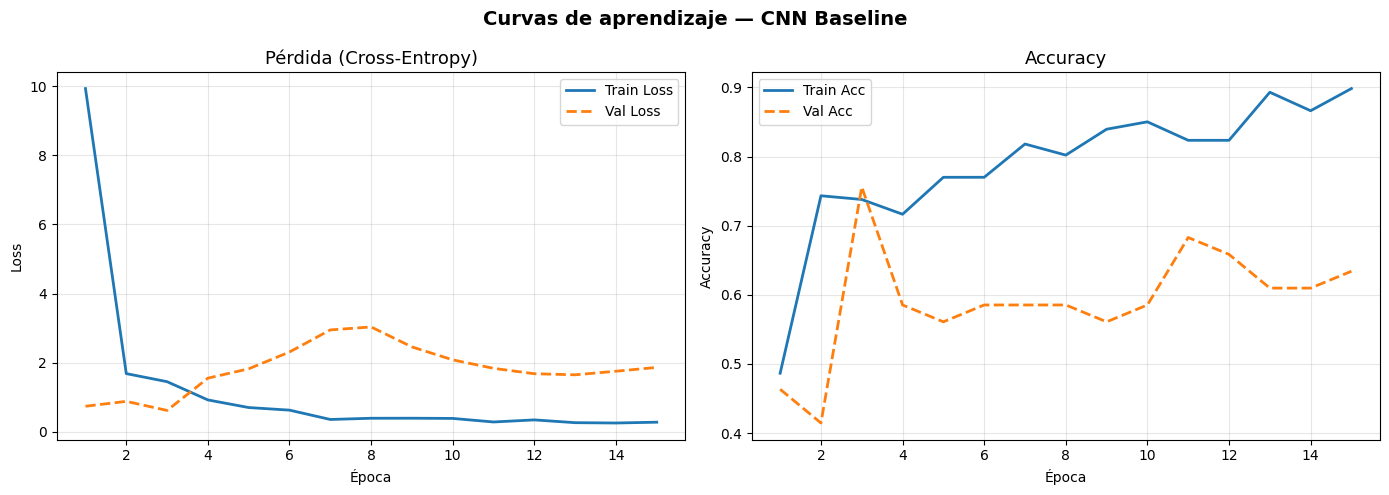

In [57]:
hist   = historia.history
epocas = range(1, len(hist['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epocas, hist['loss'],     label='Train Loss', linewidth=2)
ax1.plot(epocas, hist['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
ax1.set_title('Pérdida (Cross-Entropy)', fontsize=13)
ax1.set_xlabel('Época'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epocas, hist['accuracy'],     label='Train Acc', linewidth=2)
ax2.plot(epocas, hist['val_accuracy'], label='Val Acc',   linewidth=2, linestyle='--')
ax2.set_title('Accuracy', fontsize=13)
ax2.set_xlabel('Época'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizaje — CNN Baseline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('curvas_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluación en el conjunto de test

In [54]:
mejor_modelo   = keras.models.load_model('best_baseline_cnn.keras')
probs_test     = mejor_modelo.predict(X_test, batch_size=BATCH_SIZE)
y_pred         = np.argmax(probs_test, axis=1)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print('=' * 45)
print('     MÉTRICAS EN TEST — CNN BASELINE')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print('=' * 45)
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 246ms/step
     MÉTRICAS EN TEST — CNN BASELINE
  Accuracy  : 0.5610  (56.10%)
  Precision : 0.5537
  Recall    : 0.5610
  F1-Score  : 0.5560

              precision    recall  f1-score   support

        bart       0.62      0.67      0.64        24
       homer       0.47      0.41      0.44        17

    accuracy                           0.56        41
   macro avg       0.54      0.54      0.54        41
weighted avg       0.55      0.56      0.56        41



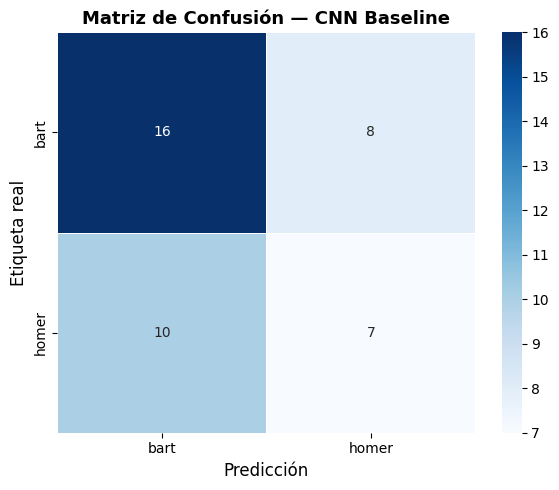

In [55]:
# ── Matriz de confusión ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Etiqueta real', fontsize=12)
ax.set_title('Matriz de Confusión — CNN Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Visualización de predicciones

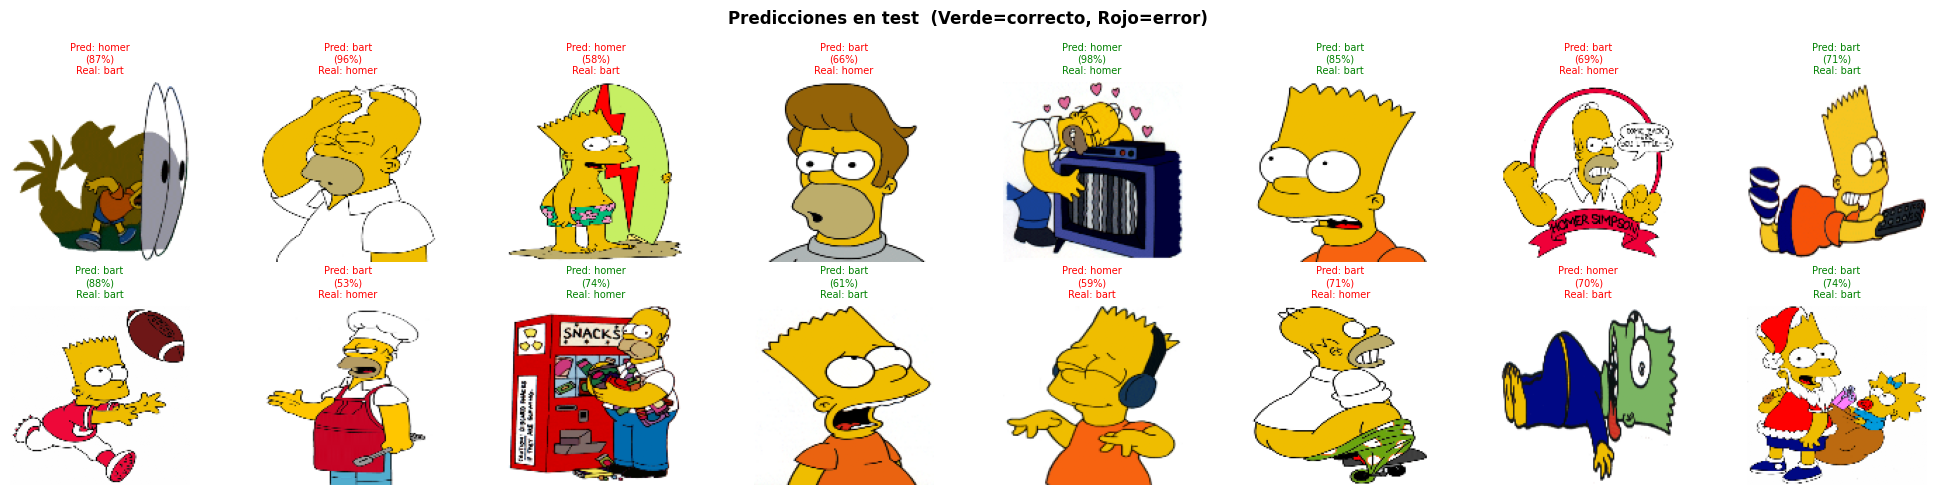

In [56]:
n_show  = 16
indices = np.random.choice(len(X_test), n_show, replace=False)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))

for i, ax in enumerate(axes.flat):
    idx      = indices[i]
    pred_cls = CLASS_NAMES[y_pred[idx]]
    true_cls = CLASS_NAMES[y_test[idx]]
    conf     = probs_test[idx][y_pred[idx]]
    color    = 'green' if pred_cls == true_cls else 'red'

    ax.imshow(X_test[idx])
    ax.set_title(f'Pred: {pred_cls}\n({conf:.0%})\nReal: {true_cls}',
                 color=color, fontsize=7)
    ax.axis('off')

plt.suptitle('Predicciones en test  (Verde=correcto, Rojo=error)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('predicciones_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Resumen y observaciones

| Métrica    | Valor |
|------------|-------|
| Accuracy   | —     |
| Precision  | —     |
| Recall     | —     |
| F1-Score   | —     |


### Limitaciones del baseline
- Dataset pequeño (~270 imágenes) → alta probabilidad de sobreajuste sin augmentation.
- CNN entrenada desde cero → features genéricas, sin conocimiento previo.
- Sin regularización adicional más allá de Dropout y BatchNorm.

### Siguientes pasos
Ver **`02_mejoras.ipynb`** donde se aplica Data Augmentation y Transfer Learning con MobileNetV2.